<a href="https://colab.research.google.com/github/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/blob/main/Lab_6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Aim: To implement a Support Vector Machine (SVM) classifier to predict Chronic Kidney Disease using the CKD dataset after performing preprocessing, feature scaling, feature selection, and model evaluation.**

Support Vector Machine (SVM) is a powerful supervised machine learning algorithm used for classification and regression tasks. It works by finding an optimal hyperplane that separates data points of different classes with the maximum margin.

The closest points to the separating boundary are called support vectors. These points influence the position of the hyperplane.

If data is not linearly separable, SVM uses kernel functions to transform the data into a higher dimensional space where separation becomes possible.

Step 1: Import required libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.svm import SVC
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

Step 2: Load dataset

In [2]:
url = "https://raw.githubusercontent.com/Tanishq-Choudhary/Tanishq-Choudhary-23FE10CSE00664-ML-Lab-Sem-6/main/data/chronic_kidney_disease_full.csv"

df = pd.read_csv(url)

df.head()

,'age','bp','sg','al','su','rbc','pc','pcc','ba','bgr',...,'pcv','wbcc','rbcc','htn','dm','cad','appet','pe','ane','class'
0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,121.0,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,NaN,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,423.0,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,117.0,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,106.0,...,35,7300,4.6,no,no,no,good,no,no,ckd


In [18]:
print("Dataset shape:", df.shape)
print("Number of features:", df.shape[1]-1)
print("Number of samples:", df.shape[0])

Dataset shape: (400, 25)
Number of features: 24
Number of samples: 400


Step 3: Clean column names.

In [3]:
df.columns = df.columns.str.strip().str.replace("'", "")

Step 4: Handle missing values.

Separate numeric & categorical columns

In [4]:
num_cols = df.select_dtypes(include=['float64','int64']).columns

cat_cols = df.select_dtypes(include=['object']).columns

Fill missing values

In [5]:
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

Step 5: Encode Categorical Variables

In [6]:
le = LabelEncoder()

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

Step 6: Define Features and Target

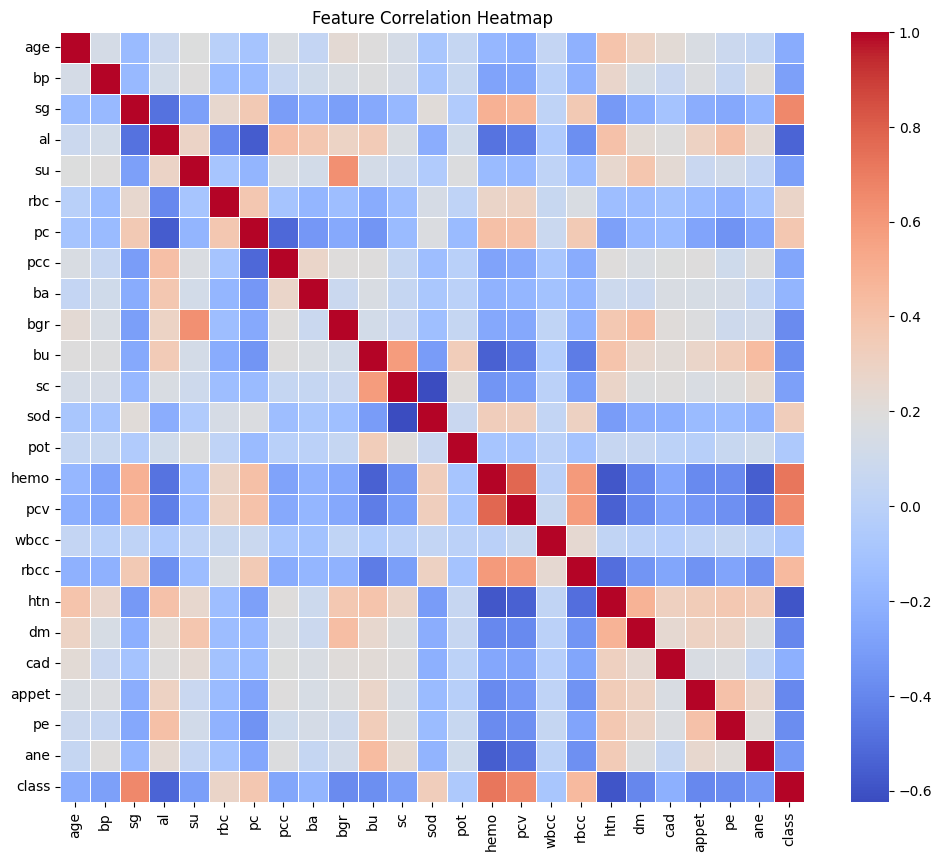

In [21]:
plt.figure(figsize=(12,10))

corr = df.corr()

sns.heatmap(corr, cmap='coolwarm', linewidths=0.5)

plt.title("Feature Correlation Heatmap")

plt.show()

In [7]:
X = df.drop('class', axis=1)

y = df['class']

Step 7: Train-Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=123
)

print("Training feature set:", X_train.shape)
print("Test feature set:", X_test.shape)

Training feature set: (280, 24)
Test feature set: (120, 24)


Step 8: Feature Scaling

SVM requires scaled features.

In [9]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

Step 9: Feature Selection

Select the most important features.

In [10]:
selector = SelectKBest(score_func=chi2, k=10)

X_train = selector.fit_transform(abs(X_train), y_train)

X_test = selector.transform(abs(X_test))

Step 10: Train the SVM Model

In [11]:
svm_model = SVC(kernel='rbf')

svm_model.fit(X_train, y_train)

SVC()

Step 11: Make Predictions

In [12]:
y_pred = svm_model.predict(X_test)

Step 12: Confusion Matrix

In [13]:
cm = confusion_matrix(y_test, y_pred)

print(cm)

[[69  9]
 [ 0 42]]


Step 13: Classification Report

In [14]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      0.88      0.94        78
           2       0.82      1.00      0.90        42

    accuracy                           0.93       120
   macro avg       0.91      0.94      0.92       120
weighted avg       0.94      0.93      0.93       120



Step 14: Accuracy Score

In [15]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.925


Step 15: Confusion Matrix Visualization

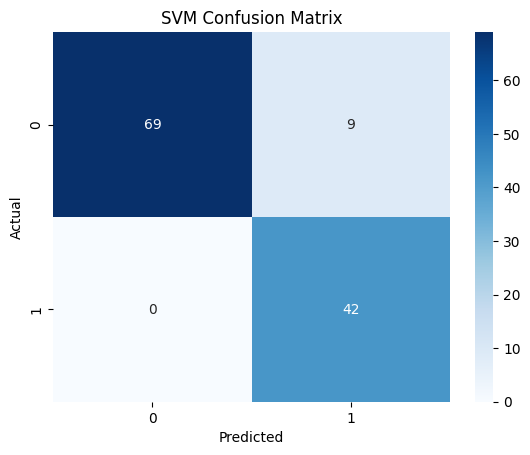

In [16]:
sns.heatmap(cm, annot=True, cmap="Blues")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("SVM Confusion Matrix")

plt.show()

Step 16: Feature Importance Visualization

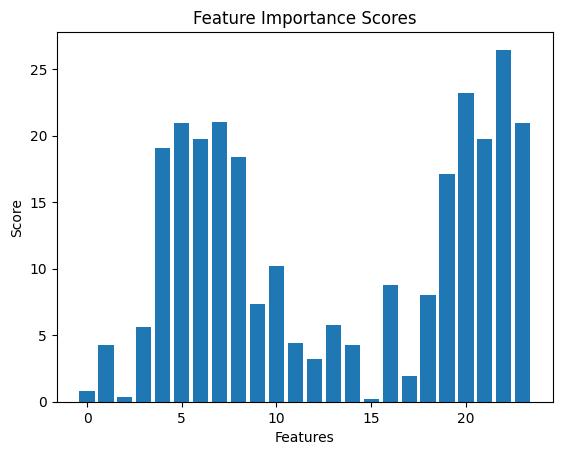

In [17]:
scores = selector.scores_

plt.bar(range(len(scores)), scores)

plt.title("Feature Importance Scores")

plt.xlabel("Features")

plt.ylabel("Score")

plt.show()

Conclusion - In this experiment, Support Vector Machine was applied to predict Chronic Kidney Disease using medical data. After preprocessing and selecting relevant features, the model was trained and evaluated using classification metrics. The results demonstrate that SVM is an effective algorithm for medical diagnosis problems due to its ability to handle high-dimensional data and nonlinear patterns.